# Imports

In [2]:
import torch
import os
import sys

import numpy as np
from src.colour_mnist import get_biased_mnist_dataloader
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from craft.craft_torch import Craft, torch_to_numpy


import matplotlib.pyplot as plt
import random as rd

2025-06-12 16:40:05.351594: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-12 16:40:05.380345: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2025-06-12 16:40:06.028888: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Parameters

In [3]:
exp_id = 0
exp_name = "MNIST"
batch_size = 256
data_path = os.getcwd() + "/data/MNIST"
train_correlation, test_correlation = 0.4, 0.1
epochs = 30
layer_depth = 4
number_of_concepts = 20
patch_size = 8
concept_dataset_size = 500

# Loading the model and dataset

In [4]:
current_path = os.getcwd()
train_dataloader = get_biased_mnist_dataloader(root=data_path, batch_size=batch_size, data_label_correlation=train_correlation, train=True)
test_dataloader = get_biased_mnist_dataloader(root=data_path, batch_size=batch_size, data_label_correlation=test_correlation, train=False)

for X, y, _ in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.l1 = nn.Sequential(nn.Linear(28*28*3, 512), nn.ReLU())
        self.l2 = nn.Sequential(nn.Linear(512, 512), nn.ReLU())
        self.l3 = nn.Sequential(nn.Linear(512, 10))

    def forward(self, x):
        x = self.flatten(x)
        x = self.l1(x)
        x = self.l2(x)
        logits = self.l3(x)
        return logits

model = NeuralNetwork().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
model

Shape of X [N, C, H, W]: torch.Size([256, 3, 28, 28])
Shape of y: torch.Size([256]) torch.int64
Using cuda device


NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (l1): Sequential(
    (0): Linear(in_features=2352, out_features=512, bias=True)
    (1): ReLU()
  )
  (l2): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): ReLU()
  )
  (l3): Sequential(
    (0): Linear(in_features=512, out_features=10, bias=True)
  )
)

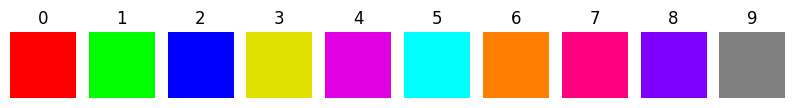

In [5]:
COLOUR_MAP = [[255, 0, 0], [0, 255, 0], [0, 0, 255], [225, 225, 0], [225, 0, 225],
                  [0, 255, 255], [255, 128, 0], [255, 0, 128], [128, 0, 255], [128, 128, 128]]
fig, axes = plt.subplots(1,10, figsize=(10,10))
for label, color in enumerate(COLOUR_MAP):
    axes[label].set_axis_off()
    axes[label].set_title(loc="center", label=f"{label}")
    axes[label].imshow([[color]])

# Training the model

In [6]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y, _) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if (batch *batch_size)% 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y, _ in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

assert(os.path.exists(f"models/{exp_name}_model_{exp_id}_{epochs}_{train_correlation}"))
model.load_state_dict(torch.load(f"models/{exp_name}_model_{exp_id}_{epochs}_{train_correlation}", weights_only=True))

test(test_dataloader, model, loss_fn)

Test Error: 
 Accuracy: 83.3%, Avg loss: 0.582465 



# Loading craft

In [7]:
g = nn.Sequential(*(list(model.children())[:layer_depth-1]))
h = nn.Sequential(*(list(model.children())[layer_depth-1:]))

craft = Craft(
    input_to_latent=g,
    latent_to_logit = h,
    number_of_concepts = number_of_concepts,
    patch_size = patch_size,
    batch_size = batch_size,
    device = device
)
g, h

(Sequential(
   (0): Flatten(start_dim=1, end_dim=-1)
   (1): Sequential(
     (0): Linear(in_features=2352, out_features=512, bias=True)
     (1): ReLU()
   )
   (2): Sequential(
     (0): Linear(in_features=512, out_features=512, bias=True)
     (1): ReLU()
   )
 ),
 Sequential(
   (0): Sequential(
     (0): Linear(in_features=512, out_features=10, bias=True)
   )
 ))

# Learning the concepts using the training dataset

In [8]:
concept_dataset = torch.Tensor([])
# for i, (_, label, _) in enumerate(train_data):
#     if label == 3:
#         dataset_3.append(i)
for X, y, y_pred in test_dataloader:
    if len(concept_dataset) >=concept_dataset_size:
        break
    concept_dataset = torch.cat((concept_dataset, X))

# ds3 = rd.sample(dataset_3, concept_dataset_size)
# ds3_im = torch.stack([train_data[i][0] for i in ds3], 0)
crops, crops_u, w = craft.fit(concept_dataset)

crops = np.moveaxis(torch_to_numpy(crops), 1, -1)

crops.shape, crops_u.shape, w.shape

/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/craft/craft_torch.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(dataset[i:i+batch_size])
/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


((8192, 8, 8, 3), (8192, 20), (20, 512))

# Estimating the used concept of a specific class

In [9]:
class_label = 0
class_dataset_size = 300

## With testing dataset

/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/craft/craft_torch.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(dataset[i:i+batch_size])


Concept 6  has an importance value of  0.6296013
Concept 12  has an importance value of  0.11092175
Concept 10  has an importance value of  0.0054365355
Concept 2  has an importance value of  0.0029358116
Concept 7  has an importance value of  0.0024164827
Concept 3  has an importance value of  0.0020325442
Concept 8  has an importance value of  0.0019381392
Concept 17  has an importance value of  0.0015070549
Concept 5  has an importance value of  0.0012242254
Concept 1  has an importance value of  0.0008217204
Concept 16  has an importance value of  0.00079145585
Concept 9  has an importance value of  0.0004401413
Concept 14  has an importance value of  0.00029335974
Concept 13  has an importance value of  0.00021694879
Concept 19  has an importance value of  0.00019903203
Concept 11  has an importance value of  8.4855405e-05
Concept 0  has an importance value of  8.244731e-05
Concept 4  has an importance value of  5.97671e-05
Concept 18  has an importance value of  5.964188e-05
Conc

/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/craft/craft_torch.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(dataset[i:i+batch_size])


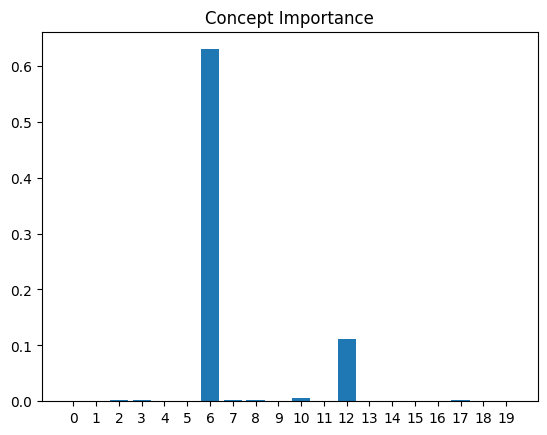

In [10]:
class_dataset = torch.Tensor([])
for X, y, y_pred in test_dataloader:
    class_dataset = torch.cat((class_dataset, X[y == class_label]))
    if len(class_dataset) >= class_dataset_size:
      class_dataset = class_dataset[:class_dataset_size]
      break


importances = craft.estimate_importance(class_dataset, class_id=class_label)
images_u = craft.transform(class_dataset)

images_u.shape

plt.bar(range(len(importances)), importances)
plt.xticks(range(len(importances)))
plt.title("Concept Importance")

most_important_concepts = np.argsort(importances)[::-1]

for c_id in most_important_concepts:
  print("Concept", c_id, " has an importance value of ", importances[c_id])

Concept 0  has an importance value of  8.244731e-05


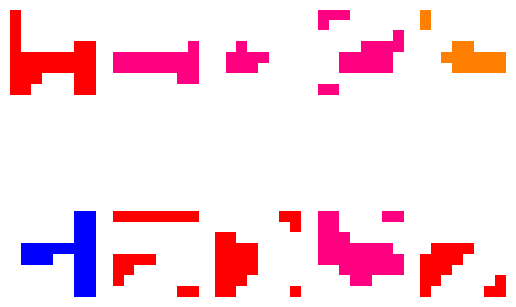




Concept 1  has an importance value of  0.0008217204


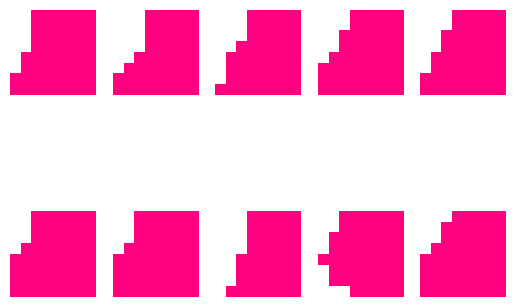




Concept 2  has an importance value of  0.0029358116


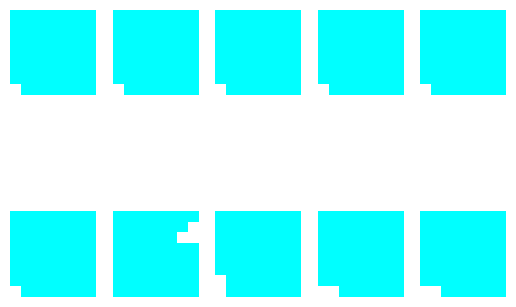




Concept 3  has an importance value of  0.0020325442


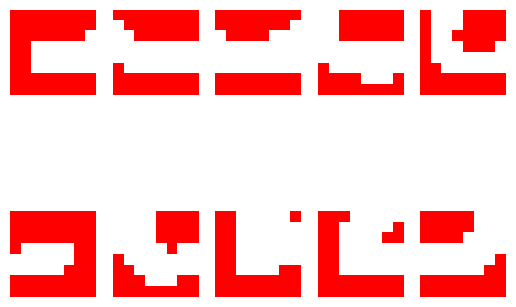




Concept 4  has an importance value of  5.97671e-05


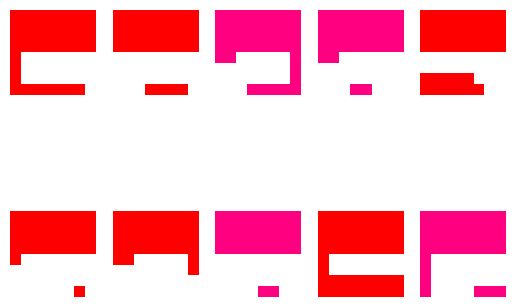




Concept 5  has an importance value of  0.0012242254


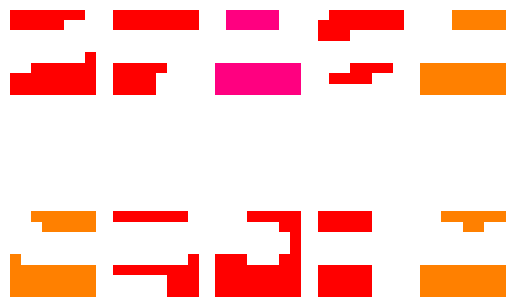




Concept 6  has an importance value of  0.6296013


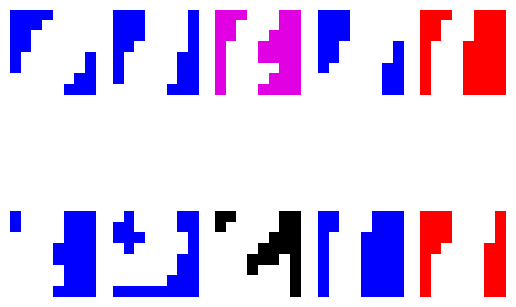




Concept 7  has an importance value of  0.0024164827


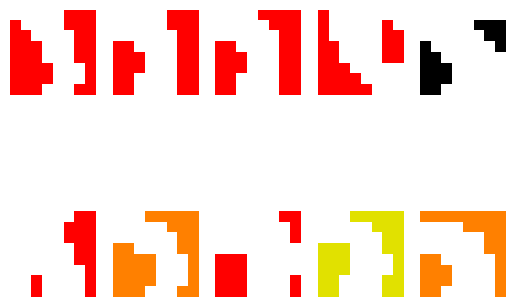




Concept 8  has an importance value of  0.0019381392


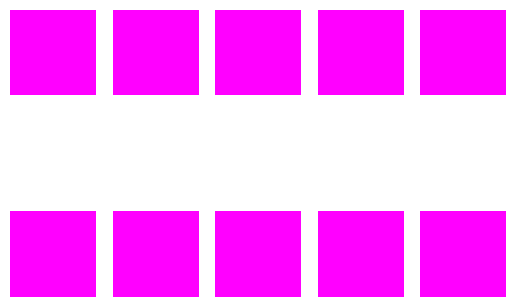




Concept 9  has an importance value of  0.0004401413


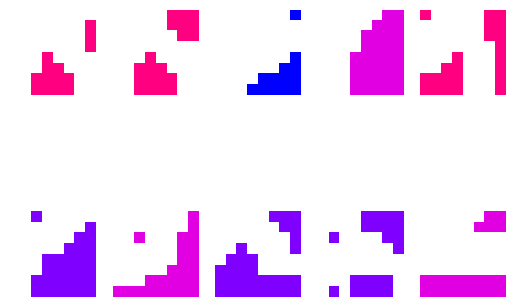




Concept 10  has an importance value of  0.0054365355


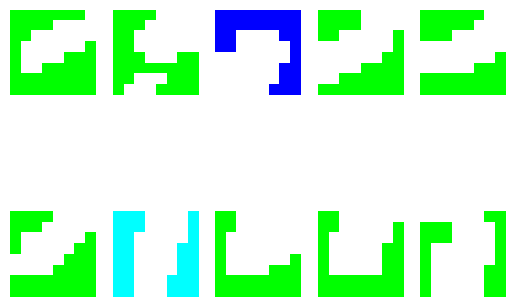




Concept 11  has an importance value of  8.4855405e-05


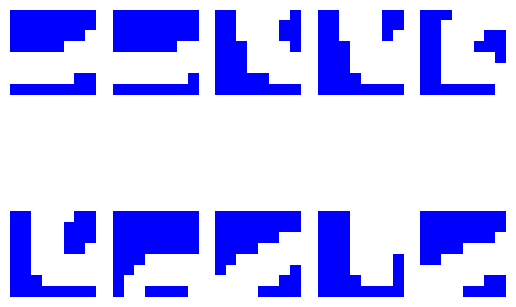




Concept 12  has an importance value of  0.11092175


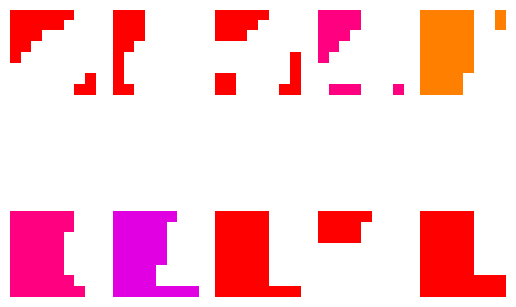




Concept 13  has an importance value of  0.00021694879


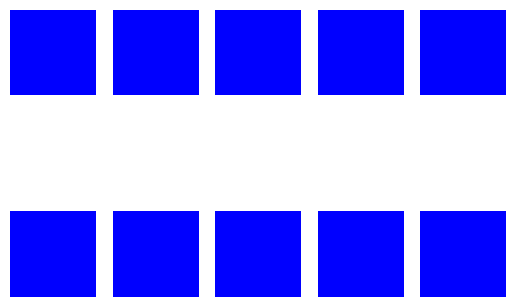




Concept 14  has an importance value of  0.00029335974


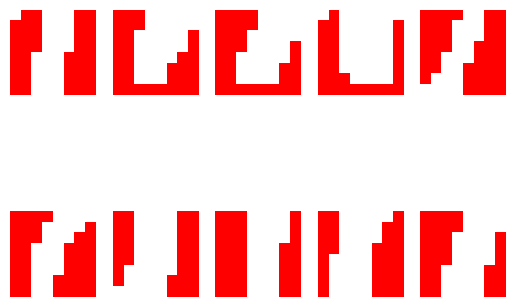




Concept 15  has an importance value of  2.919181e-05


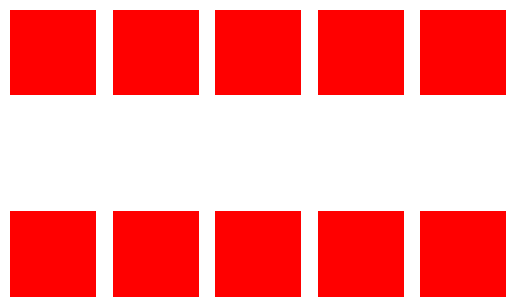




Concept 16  has an importance value of  0.00079145585


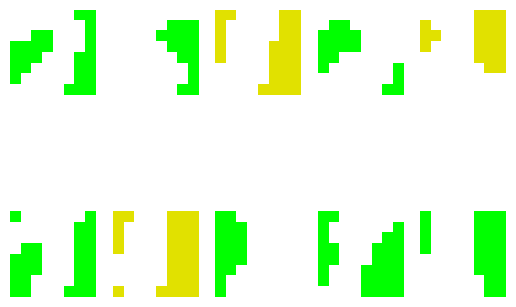




Concept 17  has an importance value of  0.0015070549


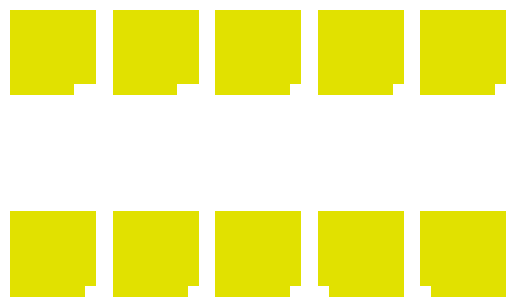




Concept 18  has an importance value of  5.964188e-05


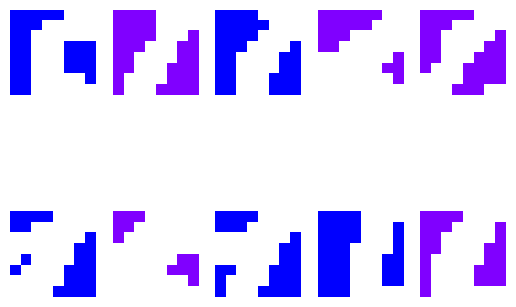




Concept 19  has an importance value of  0.00019903203


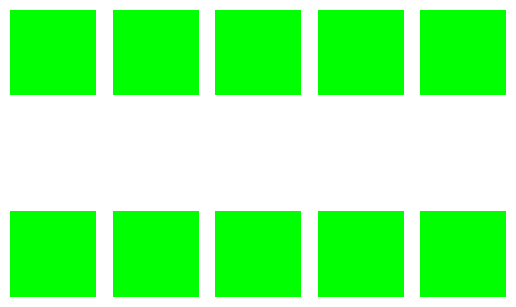

In [11]:
from math import ceil
nb_crops = 10

def show(img, **kwargs):
  img = np.array(img)
  if img.shape[0] == 3:
    img = img.transpose(1, 2, 0)

  img -= img.min();img /= img.max()
  plt.imshow(img, **kwargs); plt.axis('off')

for c_id in range(number_of_concepts):

  best_crops_ids = np.argsort(crops_u[:, c_id])[::-1][:nb_crops]
  best_crops = crops[best_crops_ids]

  print("Concept", c_id, " has an importance value of ", importances[c_id])
  for i in range(nb_crops):
    plt.subplot(ceil(nb_crops/5), 5, i+1)
    show(best_crops[i])
  plt.show()
  print('\n\n')

## With training dataset

/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/craft/craft_torch.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(dataset[i:i+batch_size])


Concept 6  has an importance value of  0.6255033
Concept 12  has an importance value of  0.108664475
Concept 10  has an importance value of  0.007634802
Concept 2  has an importance value of  0.0044015376
Concept 3  has an importance value of  0.0031817623
Concept 13  has an importance value of  0.002480188
Concept 8  has an importance value of  0.002336842
Concept 7  has an importance value of  0.0021074014
Concept 5  has an importance value of  0.0016976732
Concept 14  has an importance value of  0.0009983991


/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/craft/craft_torch.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(dataset[i:i+batch_size])


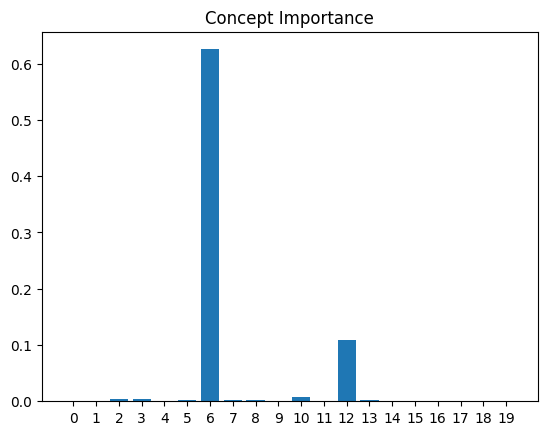

In [12]:
class_dataset = torch.Tensor([])
for X, y, y_pred in train_dataloader:
    class_dataset = torch.cat((class_dataset, X[y == class_label]))
    if len(class_dataset) >= class_dataset_size:
      class_dataset = class_dataset[:class_dataset_size]
      break


importances = craft.estimate_importance(class_dataset, class_id=class_label)
images_u = craft.transform(class_dataset)

images_u.shape

plt.bar(range(len(importances)), importances)
plt.xticks(range(len(importances)))
plt.title("Concept Importance")

most_important_concepts = np.argsort(importances)[::-1][:10]

for c_id in most_important_concepts:
  print("Concept", c_id, " has an importance value of ", importances[c_id])

Concept 6  has an importance value of  0.6255033


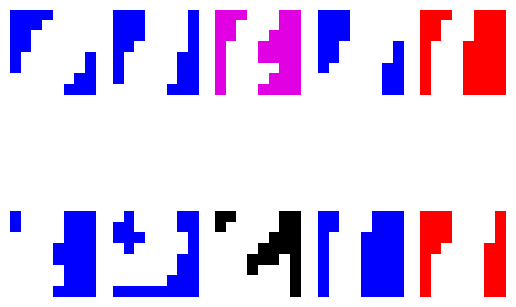




Concept 12  has an importance value of  0.108664475


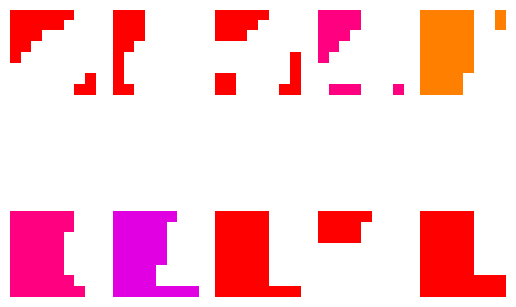




Concept 10  has an importance value of  0.007634802


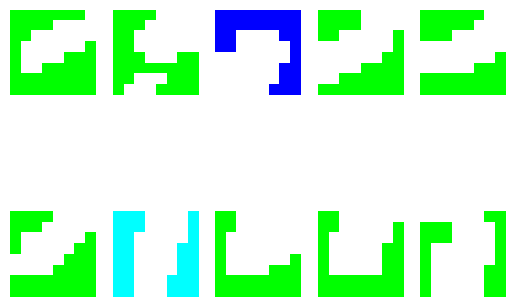




Concept 2  has an importance value of  0.0044015376


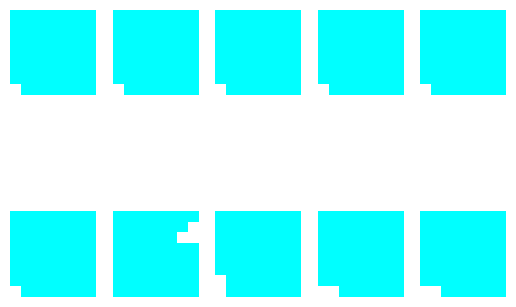




Concept 3  has an importance value of  0.0031817623


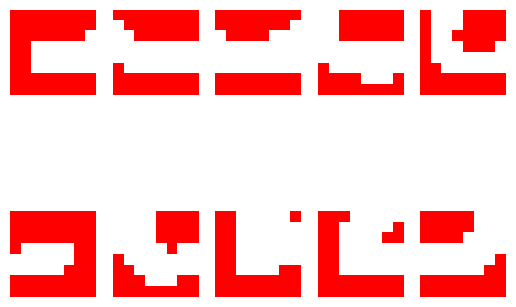




Concept 13  has an importance value of  0.002480188


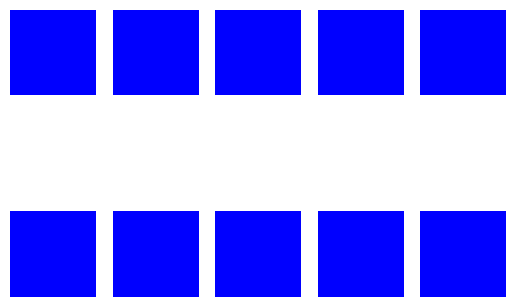




Concept 8  has an importance value of  0.002336842


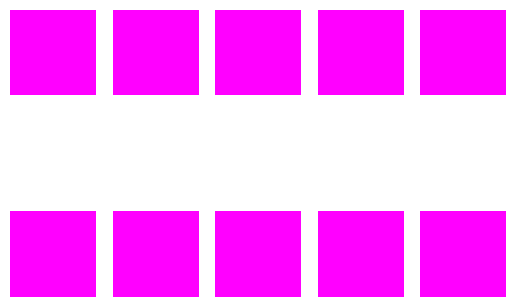




Concept 7  has an importance value of  0.0021074014


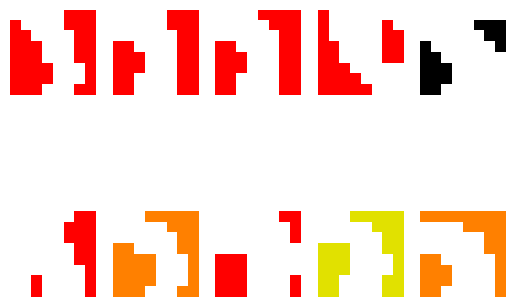




Concept 5  has an importance value of  0.0016976732


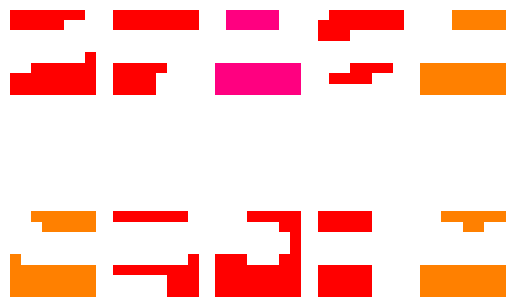




Concept 14  has an importance value of  0.0009983991


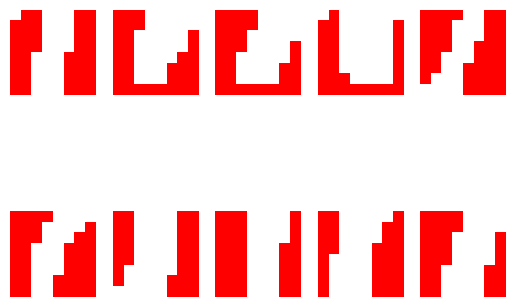

In [13]:
from math import ceil
nb_crops = 10

def show(img, **kwargs):
  img = np.array(img)
  if img.shape[0] == 3:
    img = img.transpose(1, 2, 0)

  img -= img.min();img /= img.max()
  plt.imshow(img, **kwargs); plt.axis('off')

for c_id in most_important_concepts:

  best_crops_ids = np.argsort(crops_u[:, c_id])[::-1][:nb_crops]
  best_crops = crops[best_crops_ids]

  print("Concept", c_id, " has an importance value of ", importances[c_id])
  for i in range(nb_crops):
    plt.subplot(ceil(nb_crops/5), 5, i+1)
    show(best_crops[i])
  plt.show()
  print('\n\n')

This dataset has a correlation of 0.36328125


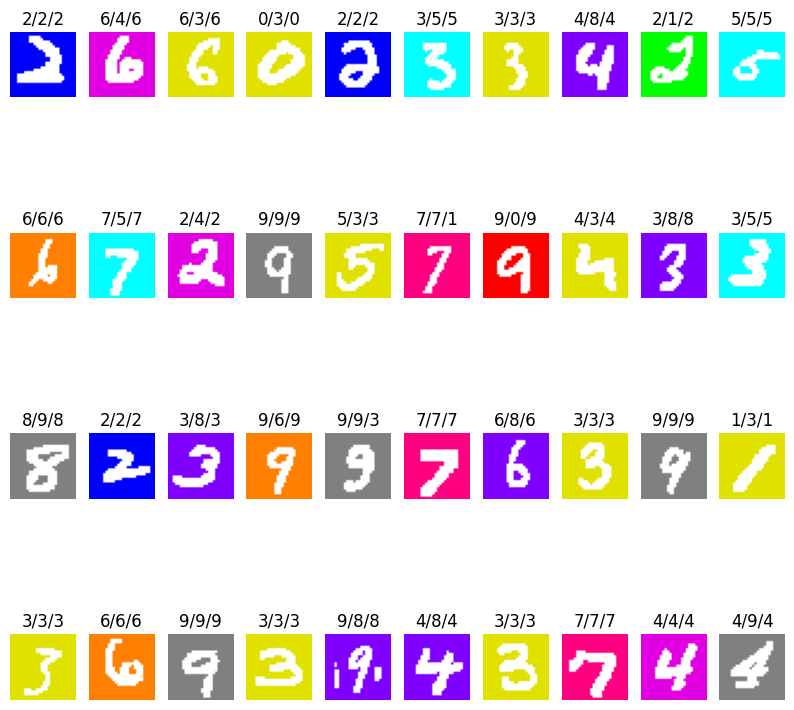

In [14]:
fig, axes = plt.subplots(4,10, figsize=(10, 10))
bias = 0
for X, y, y_pred in train_dataloader:
    y_predi = model(X.cuda()).cpu()
    for i in range(min(40, len(X))):
        axes[i//10, i%10].set_axis_off()
        axes[i//10, i%10].set_title(loc="center", label=f"{y[i]}/{y_pred[i]}/{y_predi[i].argmax()}")
        axes[i//10, i%10].imshow((X[i].permute(1, 2, 0)+1)/2)
    bias = (y == y_pred).sum()/len(y)
    break
print(f"This dataset has a correlation of {bias}")
plt.show()

# Recover the concept decomposition of an input

In [14]:
class Gradient_retriever():
    def __init__(self, layer):
        self.grad = None
        self.handle = layer.register_full_backward_hook(self._hook_function)
    
    def _hook_function(self, m, input_g, output_g):
        self.grad = torch.clone(input_g[0])
    
    def __del__(self):
        self.handle.remove()

gr = Gradient_retriever(list(model.children())[layer_depth-1])

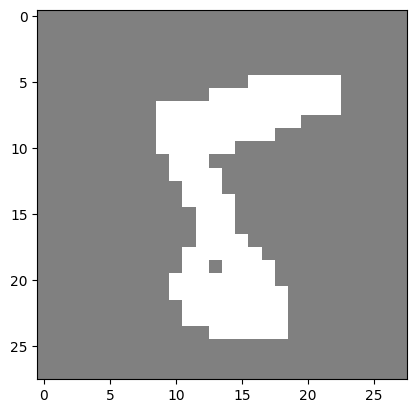

In [15]:
i = 6
inpt = X[i:i+1]
plt.imshow((X[i].permute(1, 2, 0)+1)/2)

In [49]:
activation = g(X[:30].cuda()).cpu()
u_activation = craft.transform(inputs=None, activations=activation)
inpt = X[:30]

model.eval()
model.zero_grad()
outpt = model(inpt.to(device)).cpu()
loss = loss_fn(outpt, y[:30])
# loss.backward()
# back_activation = gr.grad.cpu()


# modified_activation = activation - back_activation
# modified_activation[(modified_activation) < 0] = 0
# back_u_activation = craft.transform(inputs=None, activations = modified_activation)
# difference = (back_u_activation - u_activation)
# neg_concepts = ([],[])
# for i, el in enumerate(difference[0]):
#     if el < 0: neg_concepts[0].append(i) # These concepts are less activated when going in the right direction so they are bad for the decision
#     if el > 0: neg_concepts[1].append(i)

# # When backprop in the wrong direction
# # When backprop in the right direction
# modified_activation = activation + back_activation
# modified_activation[(modified_activation) < 0] = 0
# back_u_activation = craft.transform(inputs=None, activations = modified_activation)
# difference = (back_u_activation - u_activation)
# pos_concepts = ([],[])
# for i, el in enumerate(difference[0]):
#     if el < 0: pos_concepts[1].append(i)
#     if el > 0: pos_concepts[0].append(i)


# print("These concepts actively work against the right decision")
# print(f"By dissapearing in the right direction : {neg_concepts[0]}")
# print(f"By reinforcing in the wrong direction : {pos_concepts[0]}")


# print("\n\nThese concepts actively work for the right decision")
# print(f"By reingorcing in the right direction : {neg_concepts[1]}")
# print(f"By dissapearing in the wrong direction : {pos_concepts[1]}")


In [50]:
outpt

tensor([[-11.8162, -11.2803, -10.0033, -11.6828,  -8.1131,  -9.4358,  -9.9861,
         -12.0451,  -7.4189, -10.2668],
        [ -5.3139, -13.7405,  -8.3455,  -7.2054,  -9.6468,  -7.0042,  -8.1372,
         -10.4414,  -8.1008,  -9.9001],
        [ -7.7095, -11.8034,  -8.5878,  -6.4379,  -8.7611,  -6.0312,  -9.2229,
          -9.9648,  -7.4765,  -8.9220],
        [ -8.8110,  -9.3482,  -7.3795,  -8.7109,  -7.4891,  -6.8661,  -4.5386,
         -12.3707,  -6.2044,  -9.0070],
        [ -4.1228,  -8.8080,  -5.4634,  -3.4502,  -9.0725,  -3.9614,  -6.7652,
         -10.1908,  -5.2129,  -9.8226],
        [ -9.3043,  -1.8717,  -5.1566,  -5.8269,  -7.0954,  -6.5757,  -6.8451,
          -6.0381,  -5.4713,  -7.8168],
        [-12.0696, -12.1476, -12.4080, -10.4350,  -6.0243,  -9.0143, -11.5724,
          -7.1501,  -9.2364,  -5.6710],
        [ -5.4490,  -5.7029,  -4.1745,  -1.9409,  -6.0368,  -3.4025,  -5.6676,
          -5.7344,  -2.6152,  -4.2695],
        [ -3.8041, -12.4202,  -8.7222,  -6.8344,

In [42]:
outpt.shape

torch.Size([30, 10])

In [16]:
activation = g(X[i:i+1].cuda()).cpu()
u_activation = craft.transform(inputs=None, activations=activation)

# h.eval()
# h.zero_grad()
# out = h(activation.cuda()).cpu()
# torch.equal(out, outpt)

model.eval()
model.zero_grad()
outpt = model(inpt.to(device)).cpu()
loss = loss_fn(outpt, y[i:i+1])
loss.backward()
back_activation = gr.grad.cpu()

# Does not work because negativ values !!!
# back_u_activation = craft.transform(inputs=None, activations=back_activation)
# back_concepts = ([],[])
# for i, el in enumerate(difference[0]):
#     if el < 0: back_concepts[1].append(i) # These concepts are less activated when going in the right direction so they are bad for the decision
#     if el > 0: back_concepts[0].append(i)


# When backprop in the right direction
modified_activation = activation - back_activation
modified_activation[(modified_activation) < 0] = 0
back_u_activation = craft.transform(inputs=None, activations = modified_activation)
difference = (back_u_activation - u_activation)
neg_concepts = ([],[])
for i, el in enumerate(difference[0]):
    if el < 0: neg_concepts[0].append(i) # These concepts are less activated when going in the right direction so they are bad for the decision
    if el > 0: neg_concepts[1].append(i)

# When backprop in the wrong direction
# When backprop in the right direction
modified_activation = activation + back_activation
modified_activation[(modified_activation) < 0] = 0
back_u_activation = craft.transform(inputs=None, activations = modified_activation)
difference = (back_u_activation - u_activation)
pos_concepts = ([],[])
for i, el in enumerate(difference[0]):
    if el < 0: pos_concepts[1].append(i)
    if el > 0: pos_concepts[0].append(i)


print("These concepts actively work against the right decision")
print(f"By dissapearing in the right direction : {neg_concepts[0]}")
print(f"By reinforcing in the wrong direction : {pos_concepts[0]}")


print("\n\nThese concepts actively work for the right decision")
print(f"By reingorcing in the right direction : {neg_concepts[1]}")
print(f"By dissapearing in the wrong direction : {pos_concepts[1]}")


These concepts actively work against the right decision
By dissapearing in the right direction : [2, 3, 5, 6, 11, 13, 19]
By reinforcing in the wrong direction : [2, 3, 5, 6, 11, 19]


These concepts actively work for the right decision
By reingorcing in the right direction : [7, 9, 10, 14]
By dissapearing in the wrong direction : [7, 9, 10, 13, 14]


In [21]:
a = torch.Tensor([])
b = torch.Tensor([[1, 2, 3]])
c = torch.cat((a,b))
c

tensor([[1., 2., 3.]])

In [ ]:

def make_missclassified_dataset(dataloader, model):
    size = 0
    missclassified = None
    for X, y, y_pred in dataloader:
        y_predi = (model(X.cuda()).cpu())
        if size == 0:
            output_size = len(y_predi[0])
            missclassified = {i:{j:torch.Tensor([]) for j in range(output_size)} for i in range(output_size)}
        y_predi = y_predi.argmax(dim=1)
        wrongly_classified = (y_predi != y)
        X_wrong = X[wrongly_classified]
        y_wrong = y[wrongly_classified]
        y_pred_wrong = y_pred[wrongly_classified]
        y_predi_wrong = y_predi[wrongly_classified]
        for i in range(output_size):
            for j in range(output_size):
                missclassified[i][j] = torch.cat((missclassified[i][j], X_wrong[]))
            else:
                missclassified[int(y_wrong[i])] = X_wrong[i:i+1]
    for label, inputs in missclassified.items():
        print(f"Label {label} has {len(inputs)} examples that were missclassified")

Label 6 has 130 examples that were missclassified
Label 8 has 307 examples that were missclassified
Label 5 has 388 examples that were missclassified
Label 3 has 253 examples that were missclassified
Label 2 has 258 examples that were missclassified
Label 9 has 287 examples that were missclassified
Label 4 has 257 examples that were missclassified
Label 7 has 197 examples that were missclassified
Label 1 has 71 examples that were missclassified
Label 0 has 125 examples that were missclassified


In [42]:
good_concepts = {i:0 for i in range(number_of_concepts)}
bad_concepts = {i:0 for i in range(number_of_concepts)}
concept_activation = {i:0 for i in range(number_of_concepts)}

def make_logit_tensor(label):
    t = torch.zeros(1, 10)
    t[0][label] += 1
    return t

model.eval()
for label, inputs in missclassified.items():
    print(f"Treating label {label}")
    for i in range(len(inputs)):
        if (i%100) == 0:
            print(f"Input {i}/{len(inputs)}", end="\r")
        inpt = inputs[i:i+1]
        activation = g(inpt.cuda()).cpu()
        u_activation = craft.transform(inputs=None, activations=activation)
        for i, el in enumerate(u_activation[0]):
            concept_activation[i] += (el > 0)
    
        model.zero_grad()
        outpt = model(inpt.to(device)).cpu()
        loss = loss_fn(outpt, make_logit_tensor(label))
        loss.backward()
        back_activation = gr.grad.cpu()

        # When backprop in the right direction
        modified_activation = activation - back_activation
        modified_activation[(modified_activation) < 0] = 0
        back_u_activation = craft.transform(inputs=None, activations = modified_activation)
        difference = (back_u_activation - u_activation)
        for i, el in enumerate(difference[0]):
            if el < 0: bad_concepts[i] += 1 # These concepts are less activated when going in the right direction so they are bad for the decision
            if el > 0: good_concepts[i] += 1

        # When backprop in the wrong direction
        # When backprop in the right direction
        modified_activation = activation + back_activation
        modified_activation[(modified_activation) < 0] = 0
        back_u_activation = craft.transform(inputs=None, activations = modified_activation)
        difference = (back_u_activation - u_activation)
        for i, el in enumerate(difference[0]):
            if el < 0: good_concepts[i] += 1
            if el > 0: bad_concepts[i] += 1
    print(f"Label {label} of size {len(inputs)} successfully treated")

for key, amount in concept_activation.items():
    good_concepts[key]/=2*amount
    bad_concepts[key]/=2*amount

Treating label 6
Label 6 of size 130 successfully treated
Treating label 8


/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


Label 8 of size 307 successfully treated
Treating label 5


/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


Label 5 of size 388 successfully treated
Treating label 3


/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


Label 3 of size 253 successfully treated
Treating label 2
Label 2 of size 258 successfully treated
Treating label 9
Label 9 of size 287 successfully treated
Treating label 4
Label 4 of size 257 successfully treated
Treating label 7
Label 7 of size 197 successfully treated
Treating label 1
Label 1 of size 71 successfully treated
Treating label 0
Label 0 of size 125 successfully treated


In [43]:
good_c = list(good_concepts.items())
good_c.sort(key=lambda x : x[1])

print("The worse concepts are concepts :")
for concept, value in good_c[:int(len(good_c)/4)]:
    print(concept, end=", ")
print("\n")
print("The best concepts are concepts :")
for concept, value in good_c[int(3*len(good_c)/4):]:
    print(concept, end=", ")

The worse concepts are concepts :
3, 14, 25, 21, 7, 4, 29, 

The best concepts are concepts :
13, 23, 1, 6, 0, 17, 18, 12, 

In [44]:
bad_c = list(bad_concepts.items())
bad_c.sort(key=lambda x : x[1])

print("The worse concepts are concepts :")
for concept, value in bad_c[int(3*len(good_c)/4):]:
    print(concept, end=", ")
print("\n")
print("The best concepts are concepts :")
for concept, value in bad_c[:int(len(good_c)/4)]:
    print(concept, end=", ")

The worse concepts are concepts :
20, 21, 7, 25, 14, 9, 2, 3, 

The best concepts are concepts :
12, 18, 0, 6, 17, 1, 13, 

In [45]:
missclassified = {}

for X, y, y_pred in train_dataloader:
    y_predi = (model(X.cuda()).cpu()).argmax(dim=1)
    wrongly_classified = (y_predi != y)
    X_wrong = X[wrongly_classified]
    y_wrong = y[wrongly_classified]
    y_pred_wrong = y_pred[wrongly_classified]
    y_predi_wrong = y_predi[wrongly_classified]
    for i in range(len(y_wrong)):
        if int(y_wrong[i]) in missclassified:
            missclassified[int(y_wrong[i])] = torch.cat((missclassified[int(y_wrong[i])], X_wrong[i:i+1]))
        else:
            missclassified[int(y_wrong[i])] = X_wrong[i:i+1]
for label, inputs in missclassified.items():
    print(f"Label {label} has {len(inputs)} examples that were missclassified")

good_concepts = {i:0 for i in range(number_of_concepts)}
bad_concepts = {i:0 for i in range(number_of_concepts)}
concept_activation = {i:0 for i in range(number_of_concepts)}

def make_logit_tensor(label):
    t = torch.zeros(1, 10)
    t[0][label] += 1
    return t

model.eval()
for label, inputs in missclassified.items():
    print(f"Treating label {label}")
    for i in range(len(inputs)):
        if (i%100) == 0:
            print(f"Input {i}/{len(inputs)}", end="\r")
        inpt = inputs[i:i+1]
        activation = g(inpt.cuda()).cpu()
        u_activation = craft.transform(inputs=None, activations=activation)
        for i, el in enumerate(u_activation[0]):
            concept_activation[i] += (el > 0)
    
        model.zero_grad()
        outpt = model(inpt.to(device)).cpu()
        loss = loss_fn(outpt, make_logit_tensor(label))
        loss.backward()
        back_activation = gr.grad.cpu()

        # When backprop in the right direction
        modified_activation = activation - back_activation
        modified_activation[(modified_activation) < 0] = 0
        back_u_activation = craft.transform(inputs=None, activations = modified_activation)
        difference = (back_u_activation - u_activation)
        for i, el in enumerate(difference[0]):
            if el < 0: bad_concepts[i] += 1 # These concepts are less activated when going in the right direction so they are bad for the decision
            if el > 0: good_concepts[i] += 1

        # When backprop in the wrong direction
        # When backprop in the right direction
        modified_activation = activation + back_activation
        modified_activation[(modified_activation) < 0] = 0
        back_u_activation = craft.transform(inputs=None, activations = modified_activation)
        difference = (back_u_activation - u_activation)
        for i, el in enumerate(difference[0]):
            if el < 0: good_concepts[i] += 1
            if el > 0: bad_concepts[i] += 1
    print(f"Label {label} of size {len(inputs)} successfully treated")

for key, amount in concept_activation.items():
    good_concepts[key]/=2*amount
    bad_concepts[key]/=2*amount

good_c = list(good_concepts.items())
good_c.sort(key=lambda x : x[1])

print("\n\n")
print("The worse concepts are concepts :")
for concept, value in good_c[:int(len(good_c)/4)]:
    print(concept, end=", ")
print("\n")
print("The best concepts are concepts :")
for concept, value in good_c[int(3*len(good_c)/4):]:
    print(concept, end=", ")

bad_c = list(bad_concepts.items())
bad_c.sort(key=lambda x : x[1])
print("\n")
print("The worse concepts are concepts :")
for concept, value in bad_c[int(3*len(good_c)/4):]:
    print(concept, end=", ")
print("\n")
print("The best concepts are concepts :")
for concept, value in bad_c[:int(len(good_c)/4)]:
    print(concept, end=", ")

Label 7 has 858 examples that were missclassified
Label 9 has 1492 examples that were missclassified
Label 2 has 1113 examples that were missclassified
Label 5 has 1597 examples that were missclassified
Label 0 has 611 examples that were missclassified
Label 3 has 1273 examples that were missclassified
Label 6 has 522 examples that were missclassified
Label 8 has 1395 examples that were missclassified
Label 4 has 1093 examples that were missclassified
Label 1 has 322 examples that were missclassified
Treating label 7


/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


...

/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


Label 8 of size 1395 successfully treated
Treating label 4
Label 4 of size 1093 successfully treated
Treating label 1


/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


Label 1 of size 322 successfully treated



The worse concepts are concepts :
3, 14, 25, 29, 20, 2, 21, 

The best concepts are concepts :
13, 6, 17, 0, 23, 9, 18, 12, 

The worse concepts are concepts :
7, 21, 29, 20, 25, 14, 2, 3, 

The best concepts are concepts :
12, 18, 23, 0, 17, 6, 13, 

In [ ]:
bias_concepts = [0, 1, 2, 3, 8, 10, 16, 19]

In [46]:
class_dataset = [torch.Tensor([]) for i in range(10)]
for X, y, y_pred in test_dataloader:
  for i in range(len(class_dataset)):
    class_dataset[i] = torch.cat((class_dataset[i], X[y == i]))
for dataset in class_dataset:
  if len(class_dataset[i]) >= class_dataset_size:
    class_dataset[i] = class_dataset[i][:class_dataset_size]

print("Datasets created")
importances_class = [craft.estimate_importance(class_dataset[i], class_id=i) for i in range(len(class_dataset))]
importances_class

Datasets created


/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/craft/craft_torch.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(dataset[i:i+batch_size])
/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/craft/craft_torch.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(dataset[i:i+batch_size])
/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/craft/craft_torch.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(dataset[i:i+batch_size])
/home/thom

[array([0.00460305, 0.08663153, 0.0559294 , 0.07919363, 0.06082593,
        0.00280453, 0.03615823, 0.0068866 , 0.00774234, 0.00011506,
        0.0365952 , 0.00011992, 0.03735384, 0.07203672, 0.02584832,
        0.09228524, 0.02541145, 0.01289103, 0.00654398, 0.00347165,
        0.00965565, 0.00085776, 0.01511052, 0.01524456, 0.00031667,
        0.00055304, 0.00408983, 0.00060063, 0.00102586, 0.00115642],
       dtype=float32),
 array([7.3473647e-02, 3.0037662e-02, 1.6702451e-02, 6.9613099e-02,
        1.3547298e-01, 1.6012610e-03, 1.9459741e-02, 2.3645652e-03,
        1.0753292e-02, 7.8232188e-07, 7.3121898e-03, 2.0361021e-04,
        6.1400058e-03, 1.2983653e-02, 2.3684276e-02, 2.9245001e-04,
        1.7896320e-03, 3.8286347e-03, 3.3850435e-02, 2.6506652e-05,
        1.6150877e-03, 1.0785738e-03, 2.3935625e-02, 4.8242477e-04,
        1.3380507e-03, 5.4569432e-04, 1.5604028e-02, 1.3863118e-04,
        2.3244422e-04, 2.4710328e-04], dtype=float32),
 array([5.5407751e-02, 3.0249767e-02,

In [56]:
general_importance = sum(importances_class)
better_c = [(concept_label, value*general_importance[i]) for i, (concept_label, value) in enumerate(good_c)]
better_c.sort(key=lambda x : x[1])
worse_c = [(concept_label, value*general_importance[i]) for i, (concept_label, value) in enumerate(bad_c)]
worse_c.sort(key=lambda x : x[1])

print("\n\n")
print("The worse concepts are concepts :")
for concept, value in better_c[:int(len(better_c)/4)]:
    print(concept, end=", ")
print("\n")
print("The best concepts are concepts :")
for concept, value in better_c[int(3*len(better_c)/4):]:
    print(concept, end=", ")

print("\n")
print("The worse concepts are concepts :")
for concept, value in worse_c[int(3*len(better_c)/4):]:
    print(concept, end=", ")
print("\n")
print("The best concepts are concepts :")
for concept, value in worse_c[:int(len(better_c)/4)]:
    print(concept, end=", ")




The worse concepts are concepts :
7, 9, 0, 12, 11, 18, 4, 

The best concepts are concepts :
22, 27, 5, 10, 14, 25, 20, 29, 

The worse concepts are concepts :
24, 16, 10, 15, 18, 23, 17, 0, 

The best concepts are concepts :
26, 14, 20, 3, 9, 2, 8, 

The worse concepts are concepts :
3, 14, 25, 29, 20, 2, 21, 

The best concepts are concepts :
13, 6, 17, 0, 23, 9, 18, 12, 

The worse concepts are concepts :
7, 21, 29, 20, 25, 14, 2, 3, 

The best concepts are concepts :
12, 18, 23, 0, 17, 6, 13, 

In [58]:
diff_c = []
for label_g, value_g in good_c:
    for label_b, value_b in bad_c:
        if label_b == label_g:
            diff_c.append((label_b, value_g - value_b))
diff_c.sort(key=lambda x : x[1])
diff_c

[(3, np.float64(-0.4655570966250578)),
 (2, np.float64(-0.30295411690760526)),
 (14, np.float64(-0.26610035559067563)),
 (25, np.float64(-0.2537558685446009)),
 (20, np.float64(-0.21490496832277428)),
 (29, np.float64(-0.2061538461538462)),
 (21, np.float64(-0.19453035975907534)),
 (4, np.float64(-0.1761557900995987)),
 (8, np.float64(-0.1706714944042133)),
 (7, np.float64(-0.16923076923076918)),
 (27, np.float64(-0.141627358490566)),
 (11, np.float64(-0.13809693513898785)),
 (5, np.float64(-0.11117498275465626)),
 (22, np.float64(-0.10474495848161336)),
 (15, np.float64(-0.08530285419088213)),
 (10, np.float64(-0.08333333333333337)),
 (19, np.float64(-0.03776575904513246)),
 (16, np.float64(-0.014916918429003001)),
 (24, np.float64(-0.0015015015015015232)),
 (26, np.float64(0.05108940646130733)),
 (28, np.float64(0.06156022033645975)),
 (1, np.float64(0.07167710508002784)),
 (9, np.float64(0.07216494845360821)),
 (13, np.float64(0.08737478136428684)),
 (6, np.float64(0.101072683558350